In [ ]:
# VaR
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

years = 15 #Lookback period
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*years)

tickers = ['SPY', 'AAPL','TSLA','AMZN','MSFT']

In [ ]:
print(endDate)
print(startDate)

2026-02-01 15:35:23.567583
2011-02-05 15:35:23.567583


In [ ]:
adj_close_df = pd.DataFrame()
for ticker in tickers:
  data = yf.download(ticker, start=startDate, end=endDate)
  adj_close_df[ticker] = data[ 'Close']


/tmp/ipython-input-1169043156.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1169043156.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1169043156.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1169043156.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1169043156.py

In [ ]:
data = yf.download('SPY', start=startDate, end=endDate)


/tmp/ipython-input-984180337.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('SPY', start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed


In [ ]:
print(adj_close_df)

                   SPY        AAPL        TSLA        AMZN        MSFT
Date                                                                  
2011-02-07  100.956665   10.553250    1.538000    8.821500   21.513817
2011-02-08  101.415642   10.652817    1.632667    9.153000   21.574842
2011-02-09  101.186180   10.741594    1.547333    9.265000   21.338345
2011-02-10  101.224419   10.633025    1.548000    9.310500   20.979776
2011-02-11  101.828758   10.702303    1.550000    9.462500   20.789049
...                ...         ...         ...         ...         ...
2026-01-26  692.729980  255.410004  435.200012  238.419998  470.279999
2026-01-27  695.489990  258.269989  430.899994  244.679993  480.579987
2026-01-28  695.419983  256.440002  431.459991  243.009995  481.630005
2026-01-29  694.039978  258.279999  416.559998  241.729996  433.500000
2026-01-30  691.969971  259.480011  430.410004  239.300003  430.290009

[3768 rows x 5 columns]


In [ ]:
print(adj_close_df.shift(1))

                   SPY        AAPL        TSLA        AMZN        MSFT
Date                                                                  
2011-02-07         NaN         NaN         NaN         NaN         NaN
2011-02-08  100.956657   10.553252    1.538000    8.821500   21.513811
2011-02-09  101.415657   10.652819    1.632667    9.153000   21.574850
2011-02-10  101.186172   10.741592    1.547333    9.265000   21.338345
2011-02-11  101.224426   10.633023    1.548000    9.310500   20.979782
...                ...         ...         ...         ...         ...
2026-01-26  689.229980  248.039993  449.059998  239.160004  465.950012
2026-01-27  692.729980  255.410004  435.200012  238.419998  470.279999
2026-01-28  695.489990  258.269989  430.899994  244.679993  480.579987
2026-01-29  695.419983  256.440002  431.459991  243.009995  481.630005
2026-01-30  694.039978  258.279999  416.559998  241.729996  433.500000

[3768 rows x 5 columns]


In [ ]:
print(log_returns)

                 SPY      AAPL      TSLA      AMZN      MSFT
Date                                                        
2011-02-08  0.004536  0.009390  0.059732  0.036890  0.002833
2011-02-09 -0.002265  0.008299 -0.053682  0.012162 -0.011023
2011-02-10  0.000378 -0.010159  0.000431  0.004899 -0.016946
2011-02-11  0.005952  0.006494  0.001291  0.016194 -0.009133
2011-02-14  0.002401  0.006508 -0.007338  0.006163 -0.000734
...              ...       ...       ...       ...       ...
2026-01-26  0.005065  0.029280 -0.031351 -0.003099  0.009250
2026-01-27  0.003976  0.011135 -0.009930  0.025917  0.021665
2026-01-28 -0.000101 -0.007111  0.001299 -0.006849  0.002183
2026-01-29 -0.001986  0.007150 -0.035144 -0.005281 -0.105284
2026-01-30 -0.002987  0.004635  0.032708 -0.010103 -0.007432

[3767 rows x 5 columns]


In [ ]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)]* len(tickers))
historical_returns = (log_returns * weights).sum(axis=1)

In [ ]:
print(weights)

[0.2 0.2 0.2 0.2 0.2]


In [ ]:
print(historical_returns)

Date
2011-02-08    0.022676
2011-02-09   -0.009302
2011-02-10   -0.004279
2011-02-11    0.004160
2011-02-14    0.001400
                ...   
2026-01-26    0.001829
2026-01-27    0.010553
2026-01-28   -0.002116
2026-01-29   -0.028109
2026-01-30    0.003364
Length: 3767, dtype: float64


In [ ]:
days = 5
historical_x_days_returns = historical_returns.rolling(days).sum()

In [ ]:
print(historical_x_days_returns)

Date
2011-02-08         NaN
2011-02-09         NaN
2011-02-10         NaN
2011-02-11         NaN
2011-02-14    0.014655
                ...   
2026-01-26    0.003056
2026-01-27    0.042523
2026-01-28    0.035977
2026-01-29   -0.007622
2026-01-30   -0.014479
Length: 3767, dtype: float64


In [ ]:
cov_matrix = log_returns.cov() * 252
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [ ]:
cov_matrix

,SPY,AAPL,TSLA,AMZN,MSFT
SPY,0.029614,0.033478,0.045848,0.034489,0.033305
AAPL,0.033478,0.079858,0.061738,0.044675,0.042254
TSLA,0.045848,0.061738,0.323927,0.069731,0.054430
AMZN,0.034489,0.044675,0.069731,0.107082,0.048524
MSFT,0.033305,0.042254,0.054430,0.048524,0.066877


In [ ]:
portfolio_std_dev

np.float64(0.24853992795555607)

In [ ]:
from scipy.stats import norm
confidence_level = [0.95,0.99,0.90]
VaRs = []
for confidence_level in confidence_level:
  VaR = portfolio_value * (norm.ppf(1-confidence_level) * portfolio_std_dev * np.sqrt(days / 252) - historical_returns.mean() *days)
  VaRs.append(VaR)

In [ ]:
VaRs

[np.float64(-62113.01594088451),
 np.float64(-85971.51364032096),
 np.float64(-49394.13910032961)]

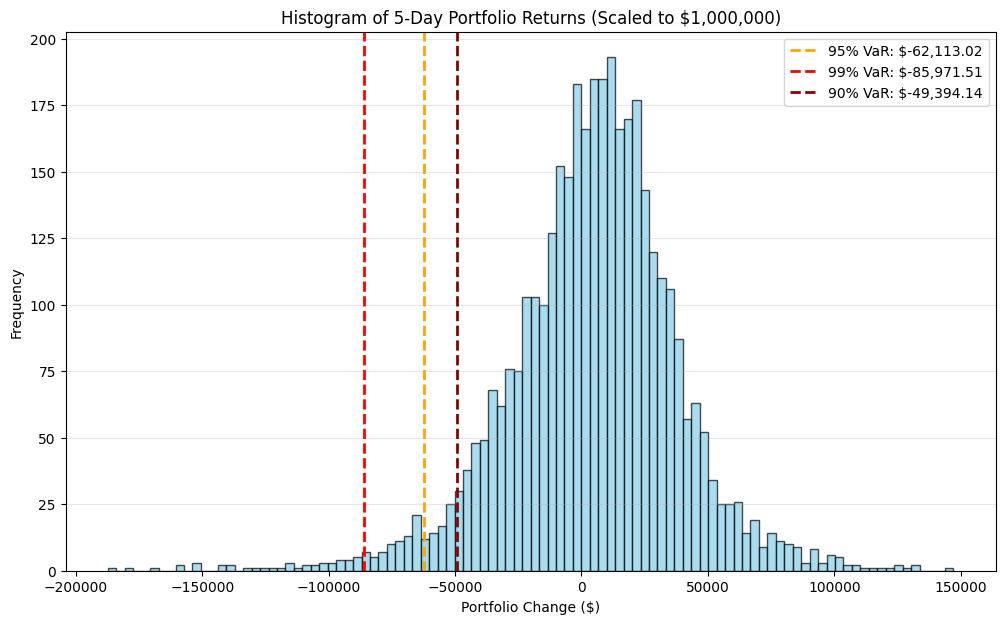

In [ ]:
import matplotlib.pyplot as plt

# Scale historical 5-day returns by portfolio value
scaled_returns = historical_x_days_returns.dropna() * portfolio_value

# Plot the histogram
plt.figure(figsize=(12, 7))
plt.hist(scaled_returns, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

# Define colors for VaR lines
colors = ['orange', 'red', 'darkred']
labels = ['95% VaR', '99% VaR', '90% VaR'] # Based on order in confidence_level list

# Overlay VaR lines
for var, color, label in zip(VaRs, colors, labels):
    plt.axvline(var, color=color, linestyle='--', linewidth=2, label=f'{label}: ${var:,.2f}')

plt.title(f'Histogram of 5-Day Portfolio Returns (Scaled to ${portfolio_value:,})')
plt.xlabel('Portfolio Change ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()